In [7]:
from game_theory_experiments import (
    CheapTalkResponse,
    BasicGamesExperimentResult,
    PrisonersDilemmaActionsType,
    BattleOfSexesActionsType
)
import matplotlib.pyplot as plt
from collections import Counter

with open("../results/prisoners_dilemma_basic.json", "r") as f:
    prisoners_dilemma_basic = BasicGamesExperimentResult[
        PrisonersDilemmaActionsType
    ].model_validate_json(f.read())

with open("../results/prisoners_dilemma_cheap_talk.json", "r") as f:
    prisoners_dillema_cheap_talk = BasicGamesExperimentResult[
        CheapTalkResponse[PrisonersDilemmaActionsType]
    ].model_validate_json(f.read())

with open("../results/battle_of_sexes_basic.json", "r") as f:
    battle_of_sexes_basic = BasicGamesExperimentResult[
        BattleOfSexesActionsType
    ].model_validate_json(f.read())

with open("../results/battle_of_sexes_cheap_talk.json", "r") as f:
    battle_of_sexes_cheap_talk = BasicGamesExperimentResult[
        CheapTalkResponse[BattleOfSexesActionsType]
    ].model_validate_json(f.read())

In [8]:
def plot_prisoners_dilemma_distribution(
    title: str, actions: list[PrisonersDilemmaActionsType]
):
    action_counts = Counter(actions)

    actions = [action for (action, count) in action_counts.most_common()]
    counts = [count for (action, count) in action_counts.most_common()]
    plt.bar(actions, counts)
    plt.title(title)
    plt.xlabel("Action")
    plt.ylabel("Count")
    plt.show()


def plot_battle_of_sexes_distribution(
    title: str, actions: list[BattleOfSexesActionsType]
):
    action_counts = Counter(actions)

    actions = [action for (action, count) in action_counts.most_common()]
    counts = [count for (action, count) in action_counts.most_common()]
    plt.bar(actions, counts)
    plt.title(title)
    plt.xlabel("Action")
    plt.ylabel("Count")
    plt.show()

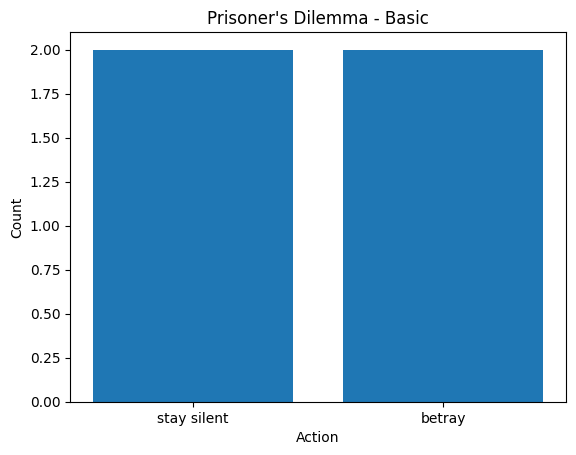

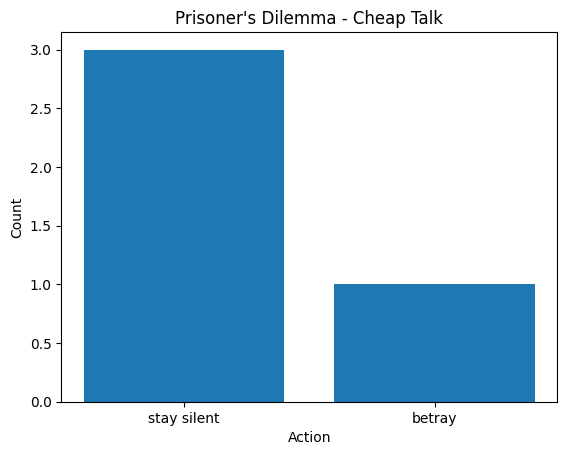

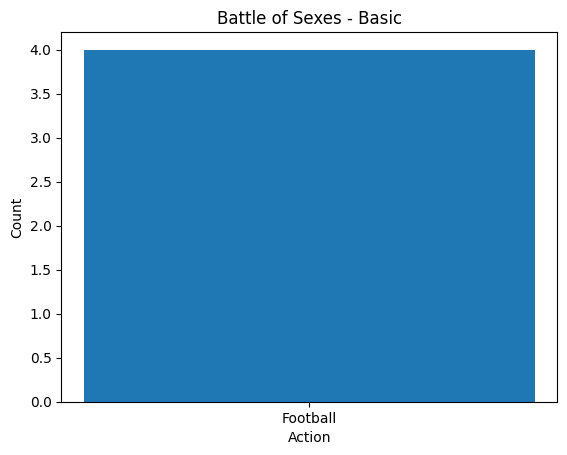

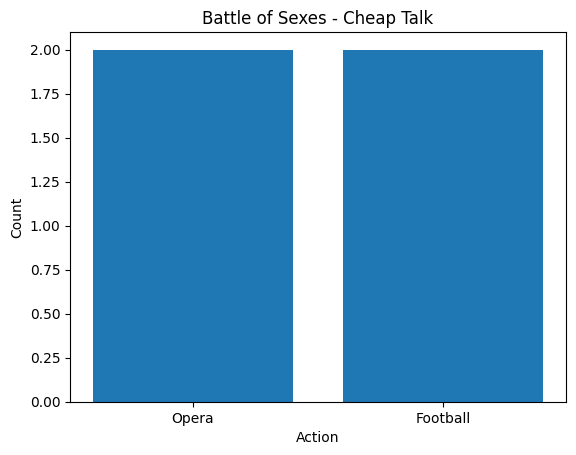

In [9]:
prisoners_dillema_basic_responses: list[PrisonersDilemmaActionsType] = [
    response.answer
    for pair in prisoners_dilemma_basic.results
    for response in pair.responses
]
prisoners_dillema_cheap_talk_responses: list[PrisonersDilemmaActionsType] = [
    response.answer.final_answer
    for pair in prisoners_dillema_cheap_talk.results
    for response in pair.responses
]

plot_prisoners_dilemma_distribution(
    "Prisoner's Dilemma - Basic", prisoners_dillema_basic_responses
)
plot_prisoners_dilemma_distribution(
    "Prisoner's Dilemma - Cheap Talk", prisoners_dillema_cheap_talk_responses
)
battle_of_sexes_basic_responses: list[BattleOfSexesActionsType] = [
    response.answer
    for pair in battle_of_sexes_basic.results
    for response in pair.responses
]
battle_of_sexes_cheap_talk_responses: list[BattleOfSexesActionsType] = [
    response.answer.final_answer
    for pair in battle_of_sexes_cheap_talk.results
    for response in pair.responses
]
plot_battle_of_sexes_distribution(
    "Battle of Sexes - Basic", battle_of_sexes_basic_responses
)
plot_battle_of_sexes_distribution(
    "Battle of Sexes - Cheap Talk", battle_of_sexes_cheap_talk_responses
)

In [10]:
from game_theory_experiments import (
    DictatorshipGameResult,
    UltimatumGameResult,
)

with open("../results/dictatorship_game.json", "r") as f:
    dictatorship_result = DictatorshipGameResult.model_validate_json(f.read())

with open("../results/ultimatum_game.json", "r") as f:
    ultimatum_result = UltimatumGameResult.model_validate_json(f.read())

In [11]:
# Extract data for visualization

# Dictatorship game: amount given by each dictator
dictatorship_amounts = [
    result.response.amount_given
    for result in dictatorship_result.results
]

# Ultimatum game: offers made by proposers
ultimatum_offers = [
    result.propose_response.offer
    for result in ultimatum_result.results
]

# Ultimatum game: acceptance decisions
ultimatum_decisions = [
    result.respond_response.decision
    for result in ultimatum_result.results
]

# Ultimatum game: accepted vs rejected counts
from collections import Counter
decision_counts = Counter(ultimatum_decisions)
print(f"Ultimatum Game - Accept: {decision_counts.get('accept', 0)}, Reject: {decision_counts.get('reject', 0)}")

Ultimatum Game - Accept: 4, Reject: 0


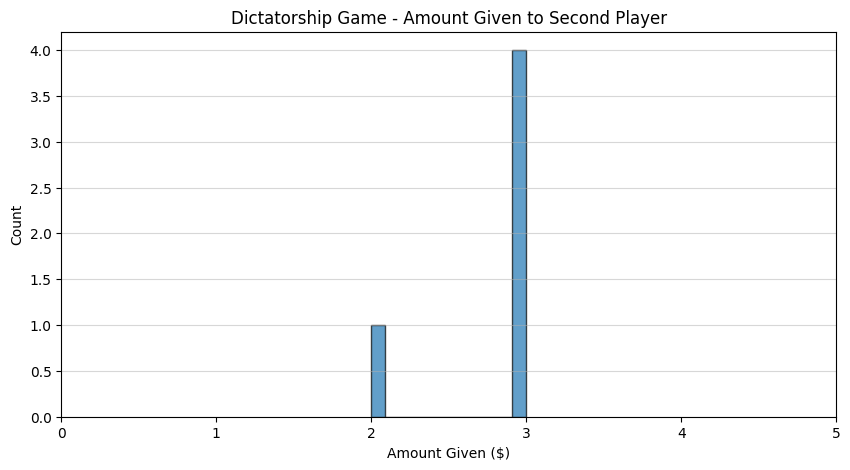

Mean amount given: 2.80


In [12]:
# Plot Dictatorship Game distribution
plt.figure(figsize=(10, 5))
plt.hist(dictatorship_amounts, bins=11, edgecolor='black', alpha=0.7)
plt.title("Dictatorship Game - Amount Given to Second Player")
plt.xlabel("Amount Given ($)")
plt.ylabel("Count")
plt.xticks(range(0, 6))
plt.grid(axis='y', alpha=0.5)
plt.show()

print(f"Mean amount given: {sum(dictatorship_amounts) / len(dictatorship_amounts):.2f}")

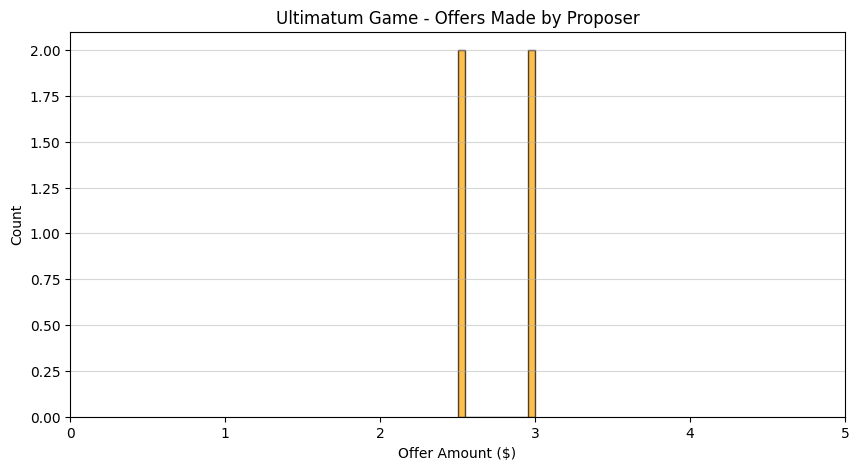

Mean offer: 2.75


In [13]:
# Plot Ultimatum Game - Offer distribution
plt.figure(figsize=(10, 5))
plt.hist(ultimatum_offers, bins=11, edgecolor='black', alpha=0.7, color='orange')
plt.title("Ultimatum Game - Offers Made by Proposer")
plt.xlabel("Offer Amount ($)")
plt.ylabel("Count")
plt.xticks(range(0, 6))
plt.grid(axis='y', alpha=0.5)
plt.show()

print(f"Mean offer: {sum(ultimatum_offers) / len(ultimatum_offers):.2f}")

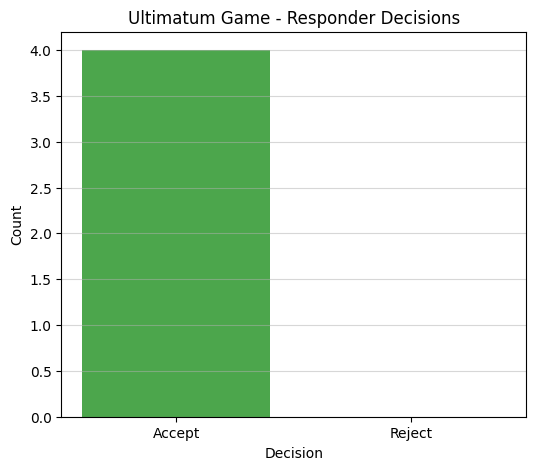

Acceptance rate: 100.0%


In [14]:
# Plot Ultimatum Game - Acceptance rate
plt.figure(figsize=(6, 5))
plt.bar(["Accept", "Reject"], [decision_counts.get("accept", 0), decision_counts.get("reject", 0)], color=['green', 'red'], alpha=0.7)
plt.title("Ultimatum Game - Responder Decisions")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.5)
plt.show()

accept_rate = decision_counts.get("accept", 0) / len(ultimatum_decisions) * 100
print(f"Acceptance rate: {accept_rate:.1f}%")

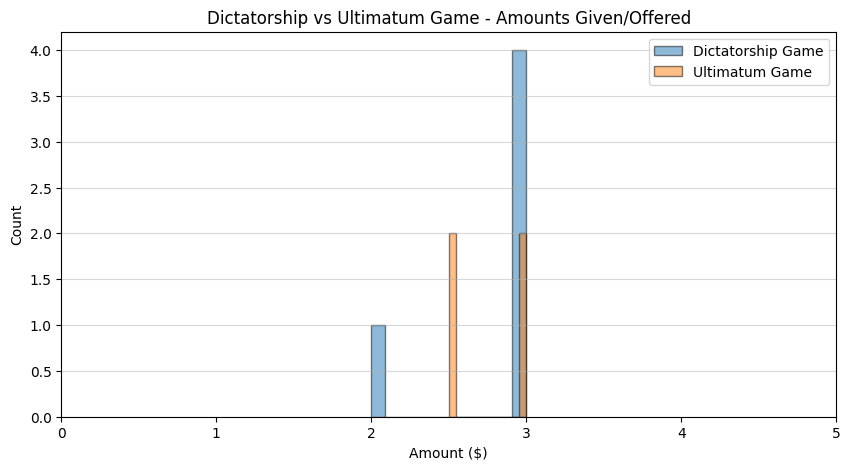

Dictatorship mean: 2.80
Ultimatum mean: 2.75


In [15]:
# Compare Dictatorship vs Ultimatum offers
plt.figure(figsize=(10, 5))
plt.hist(dictatorship_amounts, bins=11, alpha=0.5, label='Dictatorship Game', edgecolor='black')
plt.hist(ultimatum_offers, bins=11, alpha=0.5, label='Ultimatum Game', edgecolor='black')
plt.title("Dictatorship vs Ultimatum Game - Amounts Given/Offered")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
plt.xticks(range(0, 6))
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

print(f"Dictatorship mean: {sum(dictatorship_amounts) / len(dictatorship_amounts):.2f}")
print(f"Ultimatum mean: {sum(ultimatum_offers) / len(ultimatum_offers):.2f}")